# Health Insurance Charges — End-to-End ML Project

**Objective:** Build and evaluate regression models to predict individual medical insurance charges based on patient demographics, lifestyle, and policy features.

| Detail | Value |
|--------|-------|
| Dataset | insurance.csv |
| Records | 1,338 |
| Features | 6 (age, sex, bmi, children, smoker, region) |
| Target | `charges` (continuous, USD) |
| Task | Supervised Regression |

---


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

# Plot Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

print('All libraries imported successfully')

All libraries imported successfully


## 2. Data Import

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#  Load & Inspect

file_path = '/content/drive/My Drive/Datasets/insurance.csv'

try:
    df = pd.read_csv(file_path, encoding='cp1252')
    print("Dataset loaded successfully!")

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the path and try again.")

except UnicodeDecodeError:
    print("Encoding issue detected. Trying fallback encoding...")
    try:
        df = pd.read_csv(file_path, encoding='latin1')
        print("Loaded with fallback encoding (latin1).")
    except Exception as e:
        print(f"Still failed: {e}")

except Exception as e:
    print(f"An error occurred while loading the file: {e}")

Dataset loaded successfully!


In [4]:

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(10)

Shape: (1338, 7)
Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [5]:
# Data type and basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
# Summary stattistics
df.describe().round(2)

,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


## 3. Data Cleaning

In [7]:
# Check for missing values
missing = df.isnull().sum()
print("missing values per column:")
print(f"\nTotal missing: {missing.sum()}")

missing values per column:

Total missing: 0


In [8]:
# Check for duplicates
dupes = df.duplicated().sum()
print("Missing values per column:")
print(f"\nTotal duplicates: {dupes}")

# Drop duplicates
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")


Missing values per column:

Total duplicates: 1
Shape after removing duplicates: (1337, 7)


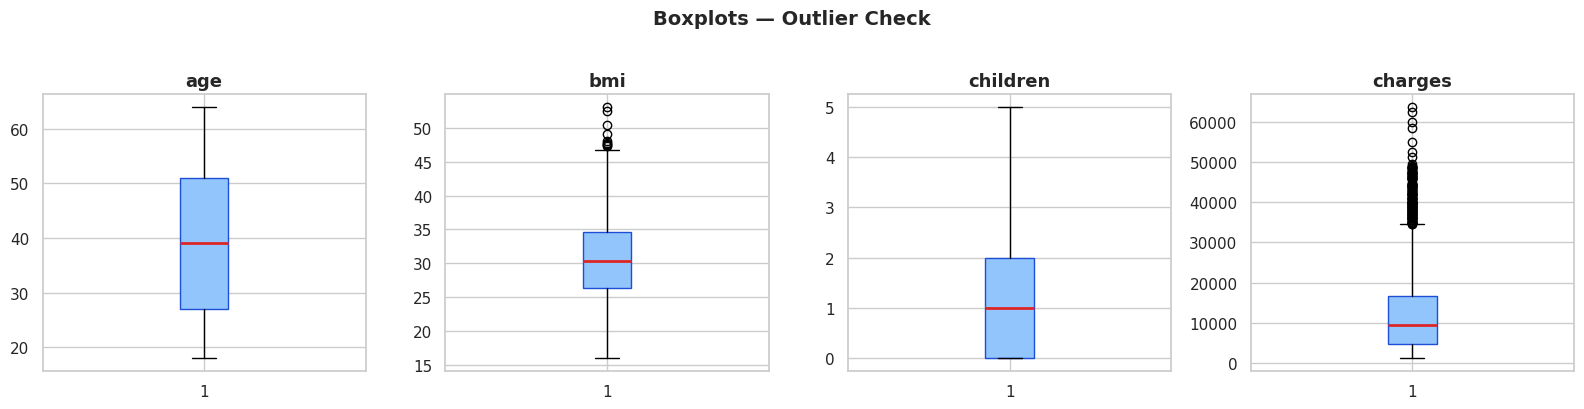

age: 0 outliers detected
bmi: 9 outliers detected
children: 0 outliers detected
charges: 139 outliers detected


In [9]:
# Check for outliers using IQR
numeric_cols = ['age', 'bmi', 'children', 'charges']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='#93c5fd', color='#1d4ed8'),
                    medianprops=dict(color='#dc2626', linewidth=2))
    axes[i].set_title(col)
    axes[i].set_xlabel('')
plt.suptitle('Boxplots — Outlier Check', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

for col in numeric_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)].shape[0]
    print(f"{col}: {outliers} outliers detected")

> **Note:** Outliers in `charges` and `bmi` reflect genuine medical variation (high-cost patients, morbid obesity). We retain them as they carry real predictive signal.

## 4. Exploratory Data Analysis - Univariate

### 4.1 Distribution of Target Variable: `charges`

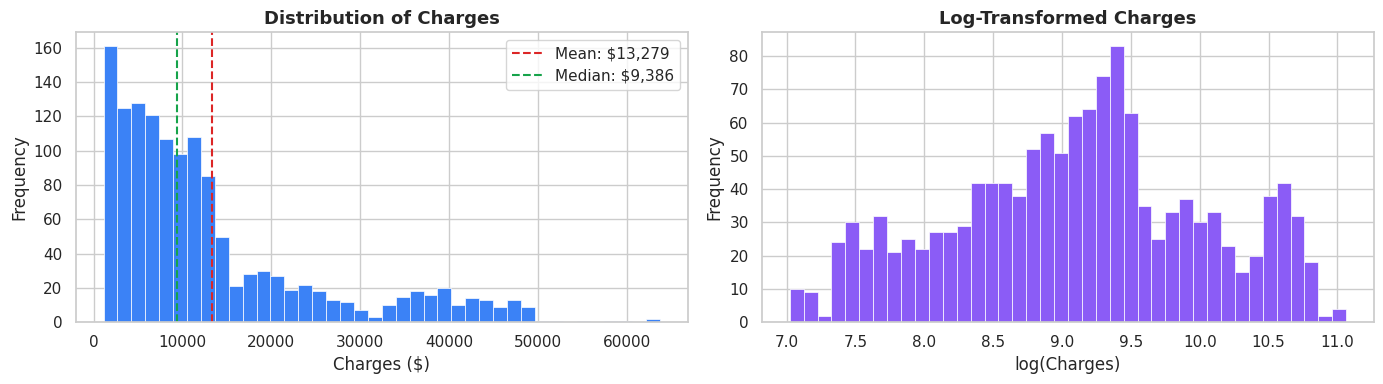

Skewness (original): 1.515
Kurtosis (original): 1.604
Skewness (log):      -0.090


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(df['charges'], bins=40, color='#3b82f6', edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribution of Charges')
axes[0].set_xlabel('Charges ($)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['charges'].mean(), color='#dc2626', linestyle='--', linewidth=1.5, label=f"Mean: ${df['charges'].mean():,.0f}")
axes[0].axvline(df['charges'].median(), color='#16a34a', linestyle='--', linewidth=1.5, label=f"Median: ${df['charges'].median():,.0f}")
axes[0].legend()

# Log-transformed
axes[1].hist(np.log(df['charges']), bins=40, color='#8b5cf6', edgecolor='white', linewidth=0.5)
axes[1].set_title('Log-Transformed Charges')
axes[1].set_xlabel('log(Charges)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Skewness (original): {df['charges'].skew():.3f}")
print(f"Kurtosis (original): {df['charges'].kurtosis():.3f}")
print(f"Skewness (log):      {np.log(df['charges']).skew():.3f}")

### 4.2 Numeric Feature Distributions

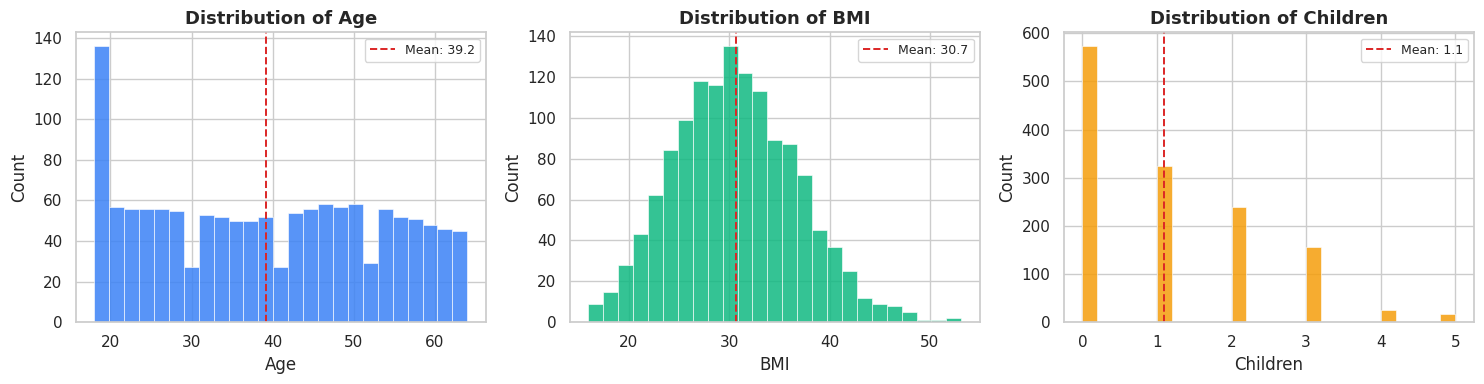

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#3b82f6', '#10b981', '#f59e0b']
labels = ['Age', 'BMI', 'Children']

for i, (col, color, label) in enumerate(zip(['age', 'bmi', 'children'], colors, labels)):
    axes[i].hist(df[col], bins=25, color=color, edgecolor='white', linewidth=0.5, alpha=0.85)
    axes[i].set_title(f'Distribution of {label}')
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Count')
    axes[i].axvline(df[col].mean(), color='#dc2626', linestyle='--', linewidth=1.4,
                    label=f'Mean: {df[col].mean():.1f}')
    axes[i].legend(fontsize=9)

plt.tight_layout()
plt.show()

### 4.3 Categorical Feature Distributions

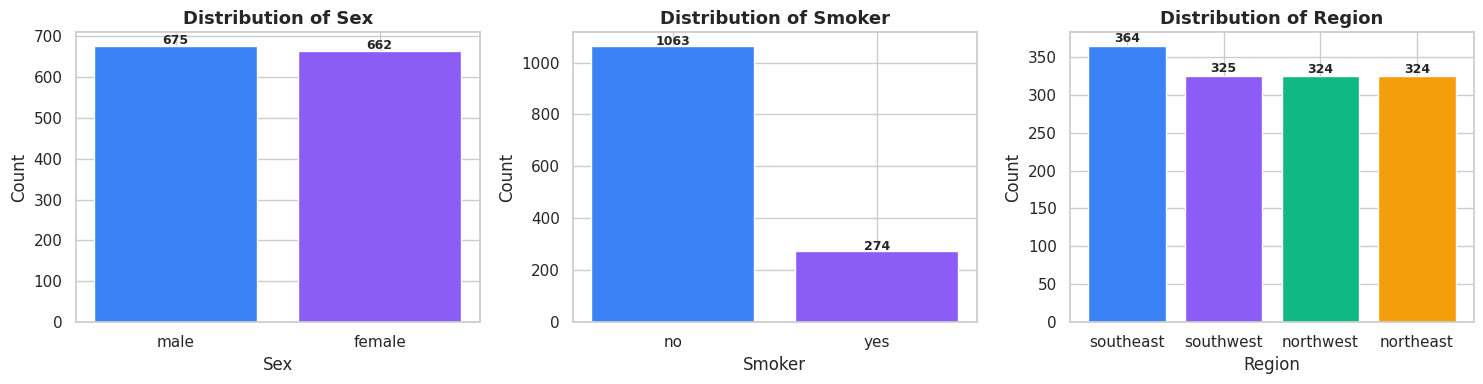


SEX:
sex
male      50.5%
female    49.5%
Name: proportion, dtype: object

SMOKER:
smoker
no     79.5%
yes    20.5%
Name: proportion, dtype: object

REGION:
region
southeast    27.2%
southwest    24.3%
northwest    24.2%
northeast    24.2%
Name: proportion, dtype: object


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cat_cols = ['sex', 'smoker', 'region']
pal = ['#3b82f6','#8b5cf6','#10b981','#f59e0b']

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color=pal[:len(counts)], edgecolor='white')
    axes[i].set_title(f'Distribution of {col.capitalize()}')
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel('Count')
    for j, v in enumerate(counts.values):
        axes[i].text(j, v + 5, str(v), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

for col in cat_cols:
    print(f"\n{col.upper()}:")
    print(df[col].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

## 5. Exploratory Data Analysis — Multivariate

### 5.1 Charges by Smoker Status

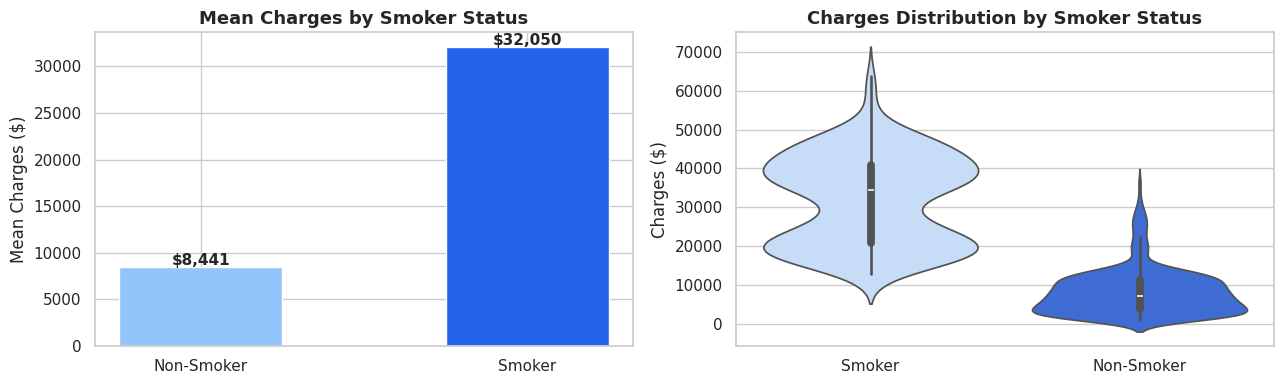

Mean charges by smoker status:
            mean    median       std
smoker                              
no       8440.66   7345.73   5992.97
yes     32050.23  34456.35  11541.55


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart
means = df.groupby('smoker')['charges'].mean()
bars = axes[0].bar(['Non-Smoker', 'Smoker'], means.values, color=['#93c5fd','#2563eb'],
                    edgecolor='white', width=0.5)
axes[0].set_title('Mean Charges by Smoker Status')
axes[0].set_ylabel('Mean Charges ($)')
for bar, val in zip(bars, means.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'${val:,.0f}', ha='center', fontweight='bold', fontsize=11)

# Violin
df_plot = df.copy()
df_plot['smoker_label'] = df_plot['smoker'].map({'no': 'Non-Smoker', 'yes': 'Smoker'})
sns.violinplot(data=df_plot, x='smoker_label', y='charges', ax=axes[1],
               palette=['#bfdbfe','#2563eb'], inner='box')
axes[1].set_title('Charges Distribution by Smoker Status')
axes[1].set_xlabel('')
axes[1].set_ylabel('Charges ($)')

plt.tight_layout()
plt.show()

print("Mean charges by smoker status:")
print(df.groupby('smoker')['charges'].agg(['mean','median','std']).round(2))

### 5.2 Charges by Age, BMI, and Region

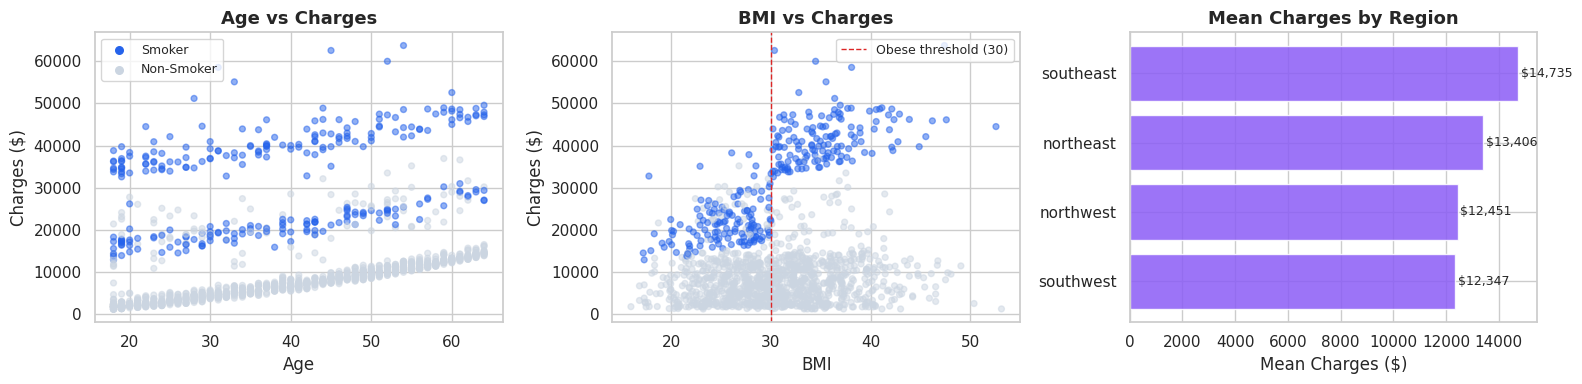

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Scatter: Age vs Charges
colors = df['smoker'].map({'yes': '#2563eb', 'no': '#cbd5e1'})
axes[0].scatter(df['age'], df['charges'], c=colors, alpha=0.5, s=18)
axes[0].set_title('Age vs Charges')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Charges ($)')
axes[0].legend(handles=[
    plt.scatter([],[], c='#2563eb', label='Smoker', s=30),
    plt.scatter([],[], c='#cbd5e1', label='Non-Smoker', s=30)
], fontsize=9)

# Scatter: BMI vs Charges
axes[1].scatter(df['bmi'], df['charges'], c=colors, alpha=0.5, s=18)
axes[1].set_title('BMI vs Charges')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Charges ($)')
axes[1].axvline(30, color='#dc2626', linestyle='--', linewidth=1, label='Obese threshold (30)')
axes[1].legend(fontsize=9)

# Region barplot
region_means = df.groupby('region')['charges'].mean().sort_values()
axes[2].barh(region_means.index, region_means.values, color='#8b5cf6', alpha=0.85)
axes[2].set_title('Mean Charges by Region')
axes[2].set_xlabel('Mean Charges ($)')
for i, v in enumerate(region_means.values):
    axes[2].text(v + 100, i, f'${v:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 5.3 Correlation Heatmap

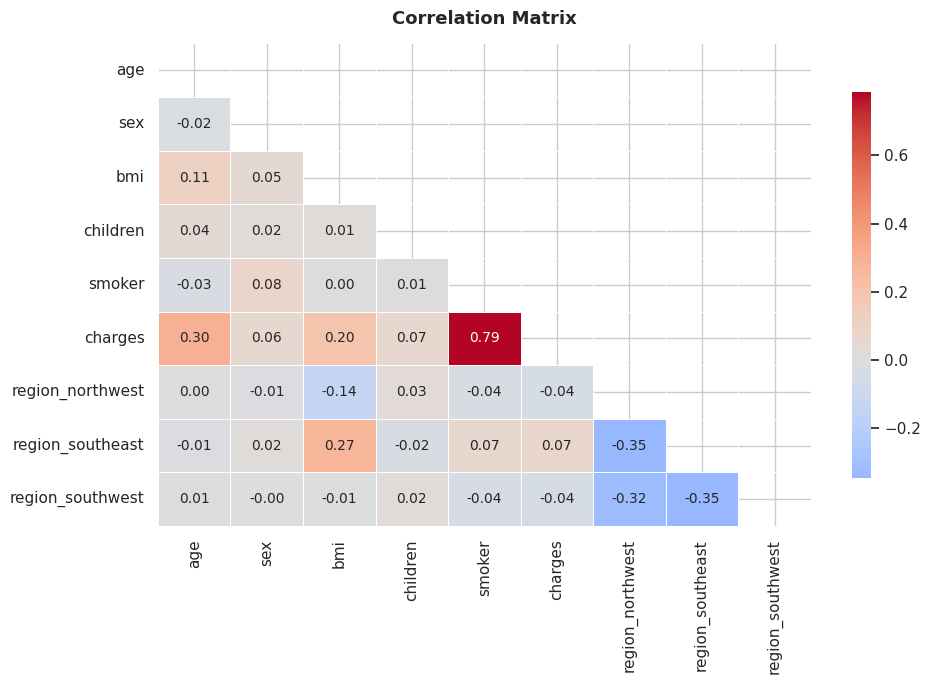


Correlation with charges (sorted):
charges             1.000
smoker              0.787
age                 0.298
bmi                 0.198
region_southeast    0.074
children            0.067
sex                 0.058
region_northwest   -0.039
region_southwest   -0.044


In [15]:
# Encode for correlation
df_corr = df.copy()
df_corr['sex']    = LabelEncoder().fit_transform(df_corr['sex'])
df_corr['smoker'] = LabelEncoder().fit_transform(df_corr['smoker'])
df_corr = pd.get_dummies(df_corr, columns=['region'], drop_first=True)

# make sure dummy columns are numeric (bool -> int), avoids any ambiguity
df_corr = df_corr.astype({col: int for col in df_corr.select_dtypes('bool').columns})

corr = df_corr.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5,
            annot_kws={'size': 10},
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix', fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

print("\nCorrelation with charges (sorted):")
print(corr['charges'].sort_values(ascending=False).round(3).to_string())

### 5.4 Charges by BMI Category & Children

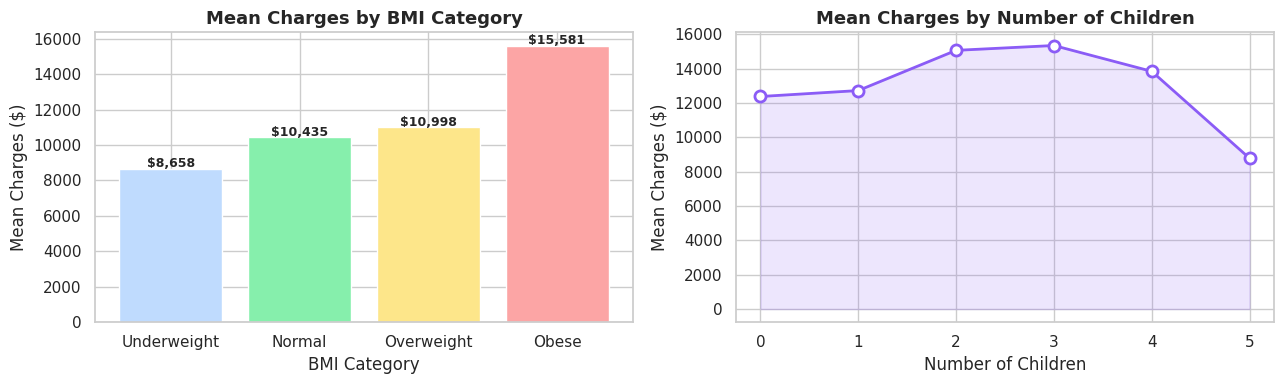

In [16]:
df['bmi_cat'] = pd.cut(df['bmi'],
                       bins=[0, 18.5, 25, 30, 100],
                       labels=['Underweight','Normal','Overweight','Obese'])
df['age_group'] = pd.cut(df['age'],
                          bins=[17, 30, 45, 55, 65],
                          labels=['18-30','31-45','46-55','56-64'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bmi_means = df.groupby('bmi_cat', observed=True)['charges'].mean()
colors_bmi = ['#bfdbfe','#86efac','#fde68a','#fca5a5']
axes[0].bar(bmi_means.index, bmi_means.values, color=colors_bmi, edgecolor='white')
axes[0].set_title('Mean Charges by BMI Category')
axes[0].set_xlabel('BMI Category')
axes[0].set_ylabel('Mean Charges ($)')
for i, v in enumerate(bmi_means.values):
    axes[0].text(i, v + 100, f'${v:,.0f}', ha='center', fontsize=9, fontweight='bold')

child_means = df.groupby('children')['charges'].mean()
axes[1].plot(child_means.index, child_means.values, marker='o', color='#8b5cf6',
             linewidth=2, markersize=8, markerfacecolor='white', markeredgewidth=2)
axes[1].fill_between(child_means.index, child_means.values, alpha=0.15, color='#8b5cf6')
axes[1].set_title('Mean Charges by Number of Children')
axes[1].set_xlabel('Number of Children')
axes[1].set_ylabel('Mean Charges ($)')
axes[1].set_xticks(child_means.index)

plt.tight_layout()
plt.show()

### 3.5 Finding: Sex shows a weak linear correlation with charges (r = 0.06),
but this masks a real confound — the apparent spread difference between

male and female charges is driven by unequal smoker rates, not sex itself.

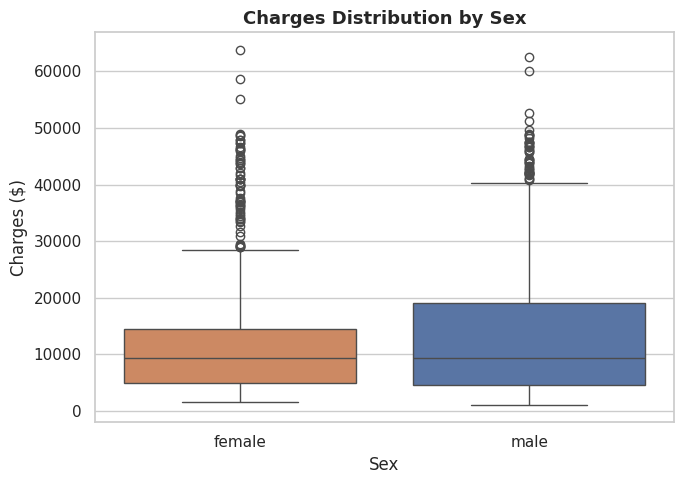

In [17]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='sex', y='charges', palette={'male':'#4C72B0','female':'#DD8452'})
plt.title('Charges Distribution by Sex', fontweight='bold')
plt.xlabel('Sex')
plt.ylabel('Charges ($)')
plt.tight_layout()
plt.show()

## 6. Feature Engineering & Preprocessing

In [18]:
# Start from clean dataframe (no derived columns)


df_model = pd.read_csv(file_path, encoding='latin1').drop_duplicates().copy()

# --- Label encoding ---
le = LabelEncoder()
df_model['sex']    = le.fit_transform(df_model['sex'])    # female=0, male=1
df_model['smoker'] = le.fit_transform(df_model['smoker']) # no=0, yes=1

# --- One-hot encode region ---
df_model = pd.get_dummies(df_model, columns=['region'], drop_first=True)

print("Features after encoding:")
print(df_model.columns.tolist())
print(f"\nShape: {df_model.shape}")
df_model.head()

Features after encoding:
['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']

Shape: (1337, 9)


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


In [19]:
# --- Train/test split ---
X = df_model.drop('charges', axis=1)
y = df_model['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set:  {X_train.shape}")
print(f"Test set:      {X_test.shape}")

# --- Feature scaling (for linear models) ---
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("\n✅ Preprocessing complete")

Training set:  (1069, 8)
Test set:      (268, 8)

✅ Preprocessing complete


## 7. Model Training & Evaluation

In [20]:
def evaluate(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    r2   = r2_score(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    mae  = mean_absolute_error(y_te, pred)
    return {'Model': name, 'R²': round(r2, 4),
            'RMSE ($)': round(rmse, 2), 'MAE ($)': round(mae, 2), '_pred': pred}

results = []

# --- Linear models (use scaled data) ---
results.append(evaluate('Linear Regression', LinearRegression(),
                         X_train_sc, X_test_sc, y_train, y_test))
results.append(evaluate('Ridge (α=10)',       Ridge(alpha=10),
                         X_train_sc, X_test_sc, y_train, y_test))
results.append(evaluate('Lasso (α=10)',       Lasso(alpha=10),
                         X_train_sc, X_test_sc, y_train, y_test))

# --- Tree-based models (raw data) ---
results.append(evaluate('Decision Tree',    DecisionTreeRegressor(max_depth=6, random_state=42),
                         X_train, X_test, y_train, y_test))
results.append(evaluate('Random Forest',    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
                         X_train, X_test, y_train, y_test))
results.append(evaluate('Gradient Boosting', GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                              max_depth=4, random_state=42),
                         X_train, X_test, y_train, y_test))

results_df = pd.DataFrame([{k:v for k,v in r.items() if k != '_pred'} for r in results])
results_df = results_df.sort_values('R²', ascending=False).reset_index(drop=True)
results_df.index += 1
results_df


,Model,R²,RMSE ($),MAE ($)
1,Gradient Boosting,0.8886,4523.42,2643.73
2,Random Forest,0.8816,4664.78,2611.53
3,Decision Tree,0.8699,4889.82,2816.47
4,Linear Regression,0.8069,5956.34,4177.05
5,Lasso (α=10),0.8065,5962.63,4178.73
6,Ridge (α=10),0.8050,5985.73,4202.58


### 7.1 Model Comparison Charts

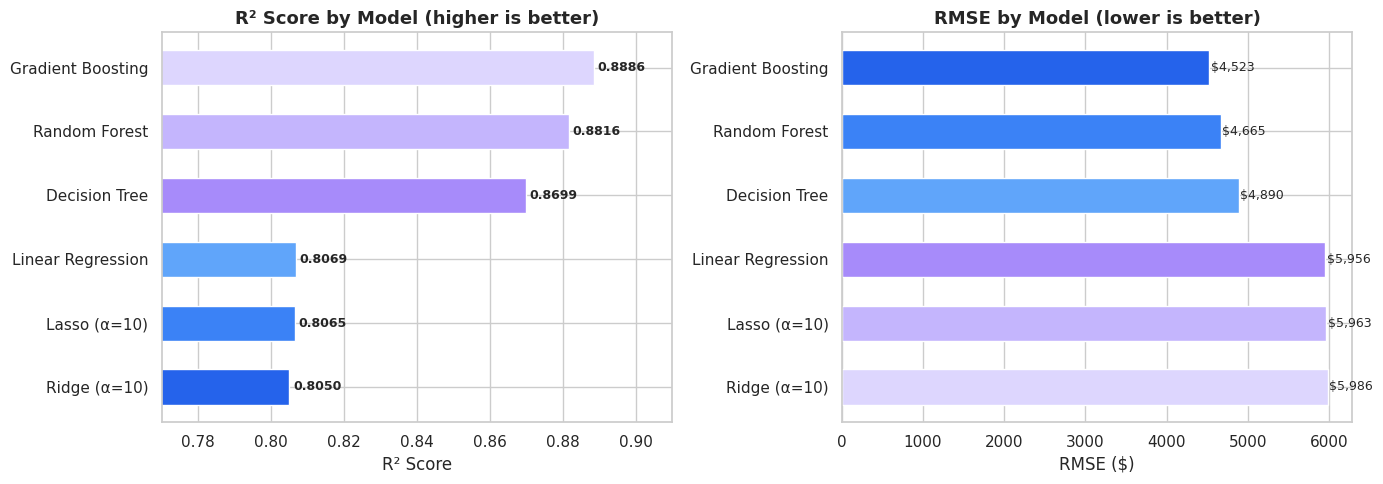

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_ord = results_df['Model'].tolist()
r2_vals    = results_df['R²'].tolist()
rmse_vals  = results_df['RMSE ($)'].tolist()

palette = ['#2563eb','#3b82f6','#60a5fa','#a78bfa','#c4b5fd','#ddd6fe']

# R² bar
bars1 = axes[0].barh(models_ord[::-1], r2_vals[::-1], color=palette, edgecolor='white', height=0.55)
axes[0].set_xlabel('R² Score')
axes[0].set_title('R² Score by Model (higher is better)')
axes[0].set_xlim(0.77, 0.91)
for bar, val in zip(bars1, r2_vals[::-1]):
    axes[0].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9, fontweight='bold')

# RMSE bar
bars2 = axes[1].barh(models_ord[::-1], rmse_vals[::-1], color=palette[::-1], edgecolor='white', height=0.55)
axes[1].set_xlabel('RMSE ($)')
axes[1].set_title('RMSE by Model (lower is better)')
for bar, val in zip(bars2, rmse_vals[::-1]):
    axes[1].text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 7.2 Best Model — Gradient Boosting: Actual vs Predicted

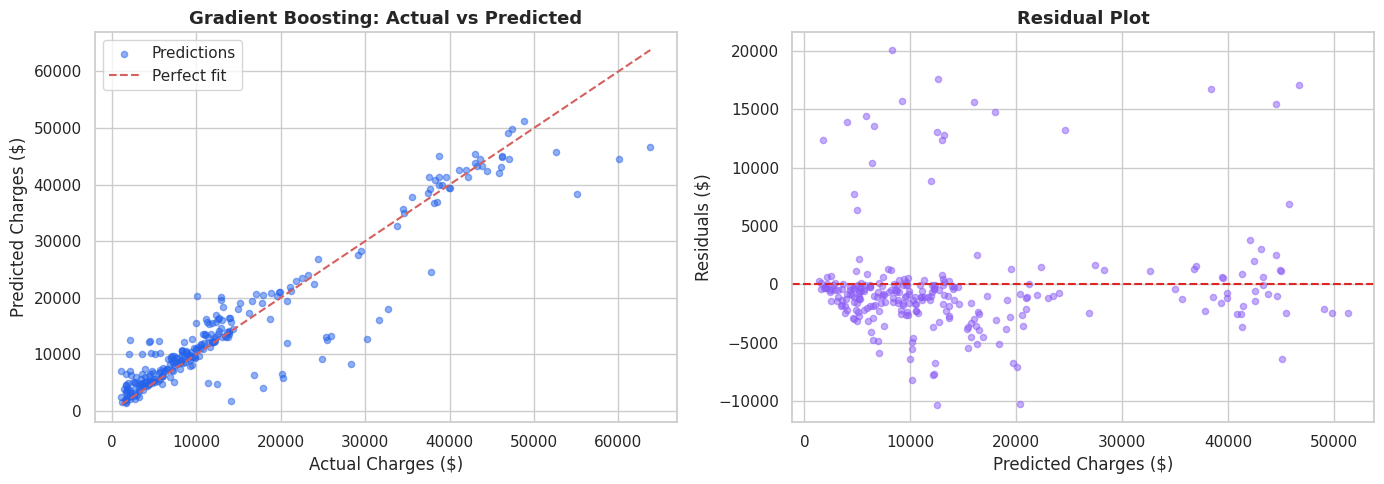

Gradient Boosting — Test Set Performance
  R²   = 0.8886
  RMSE = $4,523.42
  MAE  = $2,643.73


In [22]:
# Retrain best model
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted scatter
axes[0].scatter(y_test, y_pred_gb, alpha=0.5, color='#2563eb', s=20, label='Predictions')
min_val, max_val = y_test.min(), y_test.max()
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual Charges ($)')
axes[0].set_ylabel('Predicted Charges ($)')
axes[0].set_title('Gradient Boosting: Actual vs Predicted')
axes[0].legend()

# Residuals
residuals = y_test - y_pred_gb
axes[1].scatter(y_pred_gb, residuals, alpha=0.5, color='#8b5cf6', s=20)
axes[1].axhline(0, color='#dc2626', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Charges ($)')
axes[1].set_ylabel('Residuals ($)')
axes[1].set_title('Residual Plot')




plt.tight_layout()
plt.show()

print(f"Gradient Boosting — Test Set Performance")
print(f"  R²   = {r2_score(y_test, y_pred_gb):.4f}")
print(f"  RMSE = ${np.sqrt(mean_squared_error(y_test, y_pred_gb)):,.2f}")
print(f"  MAE  = ${mean_absolute_error(y_test, y_pred_gb):,.2f}")


## 8. Beyond RMSE — Understanding What the Error Metric Actually Tells Us

RMSE is a *typical* error magnitude, not a worst-case guarantee. Because it squares
each residual before averaging, a small number of very wrong predictions can pull
RMSE well above what most predictions actually look like. This section breaks the
single RMSE number apart to answer three business questions:

1. **How much is RMSE being inflated by outliers?** (RMSE vs MAE gap)
2. **What's the real worst-case exposure?** (max error, percentile errors)
3. **Is the error large or small relative to what we're predicting?** (RMSE as a % of typical charges)


### 8.1 RMSE vs MAE — Sizing the Outlier Effect

In [23]:
# RMSE will always be >= MAE. The SIZE of the gap tells us how much a handful
# of large-error predictions are dragging RMSE upward relative to the "typical" error.

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb  = mean_absolute_error(y_test, y_pred_gb)
gap     = rmse_gb - mae_gb
ratio   = rmse_gb / mae_gb

print("Gradient Boosting — RMSE vs MAE")
print(f"  RMSE       = ${rmse_gb:,.2f}")
print(f"  MAE        = ${mae_gb:,.2f}")
print(f"  Gap        = ${gap:,.2f}")
print(f"  RMSE / MAE = {ratio:.2f}")
print()
if ratio > 1.5:
    print("Interpretation: RMSE is substantially larger than MAE — a relatively small")
    print("number of predictions have large errors and are pulling RMSE upward.")
    print("The 'typical' miss (MAE) is meaningfully better than RMSE suggests.")
else:
    print("Interpretation: RMSE and MAE are close — errors are fairly evenly spread,")
    print("with no small subset of predictions dominating the error.")

# Same comparison across all models for context
results_df['RMSE/MAE ratio'] = (results_df['RMSE ($)'] / results_df['MAE ($)']).round(2)
results_df[['Model', 'RMSE ($)', 'MAE ($)', 'RMSE/MAE ratio']]


Gradient Boosting — RMSE vs MAE
  RMSE       = $4,523.42
  MAE        = $2,643.73
  Gap        = $1,879.68
  RMSE / MAE = 1.71

Interpretation: RMSE is substantially larger than MAE — a relatively small
number of predictions have large errors and are pulling RMSE upward.
The 'typical' miss (MAE) is meaningfully better than RMSE suggests.


,Model,RMSE ($),MAE ($),RMSE/MAE ratio
1,Gradient Boosting,4523.42,2643.73,1.71
2,Random Forest,4664.78,2611.53,1.79
3,Decision Tree,4889.82,2816.47,1.74
4,Linear Regression,5956.34,4177.05,1.43
5,Lasso (α=10),5962.63,4178.73,1.43
6,Ridge (α=10),5985.73,4202.58,1.42


### 8.2 Worst-Case Exposure — Max Error and Percentile Errors

In [24]:
# RMSE cannot tell you the worst case on its own. Here we look directly at the
# error distribution: max error, and the errors at high percentiles (90th, 95th, 99th).
# For an insurer, this answers: "how bad could the model's miss actually get, and
# how often should we expect misses of that size?"

abs_errors = np.abs(y_test - y_pred_gb)

percentiles = [50, 75, 90, 95, 99, 100]
error_percentiles = np.percentile(abs_errors, percentiles)

error_summary = pd.DataFrame({
    'Percentile': [f'{p}th' if p != 100 else 'Max (100th)' for p in percentiles],
    'Absolute Error ($)': error_percentiles.round(2)
})
error_summary.index += 1

print(f"RMSE            = ${rmse_gb:,.2f}")
print(f"MAE             = ${mae_gb:,.2f}")
print(f"Max error       = ${abs_errors.max():,.2f}")
print(f"Worst 5% of predictions are off by at least ${np.percentile(abs_errors, 95):,.2f}")
print()
error_summary


RMSE            = $4,523.42
MAE             = $2,643.73
Max error       = $20,058.11
Worst 5% of predictions are off by at least $12,637.46



,Percentile,Absolute Error ($)
1,50th,1318.97
2,75th,2639.93
3,90th,6739.88
4,95th,12637.46
5,99th,16841.54
6,Max (100th),20058.11


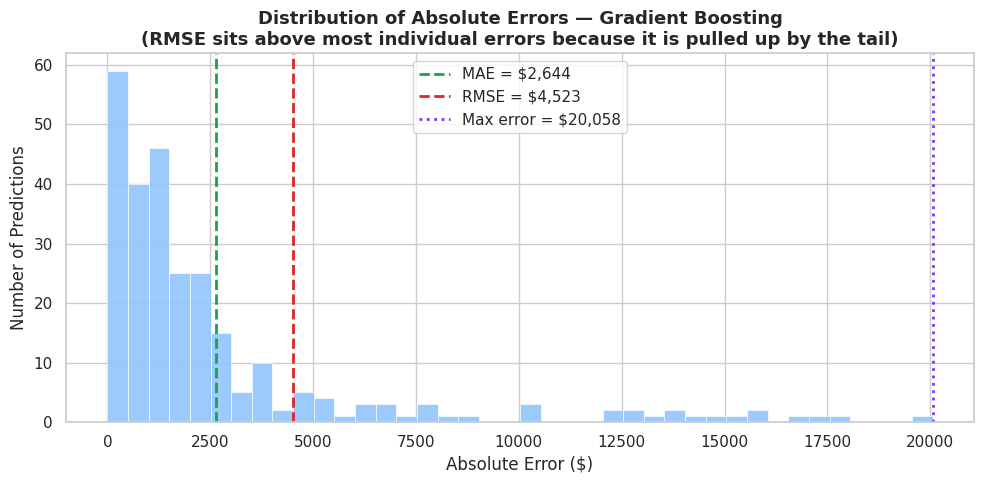

In [25]:
# Visualize the distribution of absolute errors, with RMSE and MAE marked.
# This makes the "RMSE is an average, not a ceiling" point visually obvious —
# most errors cluster well below RMSE, with a thin right tail driving it up.

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(abs_errors, bins=40, color='#93c5fd', edgecolor='white', linewidth=0.5, alpha=0.9)
ax.axvline(mae_gb, color='#16a34a', linestyle='--', linewidth=2, label=f'MAE = ${mae_gb:,.0f}')
ax.axvline(rmse_gb, color='#dc2626', linestyle='--', linewidth=2, label=f'RMSE = ${rmse_gb:,.0f}')
ax.axvline(abs_errors.max(), color='#7c3aed', linestyle=':', linewidth=2, label=f'Max error = ${abs_errors.max():,.0f}')

ax.set_xlabel('Absolute Error ($)')
ax.set_ylabel('Number of Predictions')
ax.set_title('Distribution of Absolute Errors — Gradient Boosting\n(RMSE sits above most individual errors because it is pulled up by the tail)')
ax.legend()
plt.tight_layout()
plt.show()


### 8.3 RMSE Relative to Scale — Is the Error Actually Large?

In [26]:
# A $2,000 RMSE means something very different depending on what's being predicted.
# Normalizing RMSE against the target's mean (and against its standard deviation)
# turns it into a relative, business-interpretable figure.

mean_charge = y_test.mean()
std_charge  = y_test.std()

rmse_pct_of_mean = rmse_gb / mean_charge * 100
mae_pct_of_mean  = mae_gb / mean_charge * 100
rmse_to_std      = rmse_gb / std_charge  # analogous to 1 - R² relationship

print(f"Mean charge in test set      = ${mean_charge:,.2f}")
print(f"Std dev of charges           = ${std_charge:,.2f}")
print()
print(f"RMSE as % of mean charge     = {rmse_pct_of_mean:.1f}%")
print(f"MAE as % of mean charge      = {mae_pct_of_mean:.1f}%")
print(f"RMSE / Std Dev of charges    = {rmse_to_std:.3f}  (lower = model explains more variance than a flat average would)")


Mean charge in test set      = $14,272.01
Std dev of charges           = $13,581.03

RMSE as % of mean charge     = 31.7%
MAE as % of mean charge      = 18.5%
RMSE / Std Dev of charges    = 0.333  (lower = model explains more variance than a flat average would)


### 8.4 Business Takeaway

- **RMSE is a typical-magnitude error, not a worst-case bound.** The gap between RMSE and MAE shows how much a small set of high-error predictions inflates it.
- **The real worst-case exposure** is the max error and the high percentiles (90th/95th/99th) — those are the numbers that should inform pricing buffers, reserve requirements, or manual-review thresholds for high-risk cases.
- **Scale matters.** RMSE expressed as a percentage of average charges tells stakeholders whether the error is proportionally small or large, which is more actionable than a raw dollar figure in isolation.

For a pricing or underwriting decision, the practical recommendation is: use RMSE/MAE to describe expected day-to-day model performance, but size any risk buffer or manual-review threshold off the 90th–99th percentile error, not RMSE alone.


## 9. Deployment Prep — Prediction Intervals, Outlier Flagging & Model Export

Section 8 showed that RMSE hides a thin tail of large-error predictions. In production
we won't have `y_test` to check against — so we need a way to flag "this prediction is
probably unreliable" **at inference time, using only the inputs**.

The approach:
1. Train two extra Gradient Boosting models using **quantile loss** (5th and 95th percentile)
   alongside the existing mean-prediction model. The gap between the 5th and 95th percentile
   predictions is a per-prediction **confidence interval** — wide interval = low confidence.
2. Pick a **flagging threshold** for interval width using the test set.
3. Export everything (`model`, quantile models, encoding rules, threshold) with `joblib` so a
   separate app can load and use them without retraining.


### 9.1 Train Quantile Models for Prediction Intervals

In [27]:
# Two extra GBR models trained with quantile loss instead of squared error.
# alpha=0.05 -> predicts the 5th percentile (low bound)
# alpha=0.95 -> predicts the 95th percentile (high bound)
# The gap between them is a per-row confidence interval, without needing ground truth.

gb_lower = GradientBoostingRegressor(
    loss='quantile', alpha=0.05,
    n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42
)
gb_upper = GradientBoostingRegressor(
    loss='quantile', alpha=0.95,
    n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42
)

gb_lower.fit(X_train, y_train)
gb_upper.fit(X_train, y_train)

pred_lower = gb_lower.predict(X_test)
pred_upper = gb_upper.predict(X_test)
interval_width = pred_upper - pred_lower

# Sanity check: how often does the actual value fall inside the predicted interval?
# For a well-calibrated 90% interval (5th-95th), this should be close to 90%.
coverage = ((y_test >= pred_lower) & (y_test <= pred_upper)).mean()

print(f"Mean interval width       = ${interval_width.mean():,.2f}")
print(f"Median interval width     = ${np.median(interval_width):,.2f}")
print(f"90% interval coverage     = {coverage:.1%}  (target: ~90%)")


Mean interval width       = $14,345.95
Median interval width     = $14,739.83
90% interval coverage     = 86.2%  (target: ~90%)


### 9.2 Set the Outlier / Low-Confidence Flagging Threshold

In [28]:
# Flag a prediction as "low confidence — recommend manual review" when its interval
# is unusually wide relative to the rest of the test set. We use the 90th percentile
# of interval widths observed on the test set as the cutoff — i.e. the widest 10% of
# intervals get flagged. This threshold is what ships with the app; it does not
# depend on knowing the true charge at inference time.

flag_threshold = np.percentile(interval_width, 90)
flagged = interval_width > flag_threshold

print(f"Flag threshold (90th pct of interval width) = ${flag_threshold:,.2f}")
print(f"Predictions flagged in test set              = {flagged.sum()} / {len(flagged)} ({flagged.mean():.1%})")
print()

# Does flagging actually catch the high-error cases? Compare average absolute error
# for flagged vs unflagged predictions -- this validates that wide intervals really
# do correspond to worse predictions.
flagged_error   = np.abs(y_test - y_pred_gb)[flagged].mean()
unflagged_error = np.abs(y_test - y_pred_gb)[~flagged].mean()

print(f"Avg abs error — flagged predictions    = ${flagged_error:,.2f}")
print(f"Avg abs error — unflagged predictions  = ${unflagged_error:,.2f}")
print(f"Flagging catches errors ~{flagged_error/unflagged_error:.1f}x larger than average")


Flag threshold (90th pct of interval width) = $20,220.40
Predictions flagged in test set              = 27 / 268 (10.1%)

Avg abs error — flagged predictions    = $3,450.42
Avg abs error — unflagged predictions  = $2,553.36
Flagging catches errors ~1.4x larger than average


### 9.3 Export Model Artifacts for Deployment

In [29]:
import joblib
import os

os.makedirs('model_artifacts', exist_ok=True)

# Save the three models
joblib.dump(gb,        'model_artifacts/gb_model.pkl')
joblib.dump(gb_lower,  'model_artifacts/gb_lower.pkl')
joblib.dump(gb_upper,  'model_artifacts/gb_upper.pkl')

# Save everything the app needs to replicate preprocessing exactly
metadata = {
    'feature_columns': X_train.columns.tolist(),   # exact column order the models expect
    'sex_map':    {'female': 0, 'male': 1},
    'smoker_map': {'no': 0, 'yes': 1},
    'region_categories': ['northeast', 'northwest', 'southeast', 'southwest'],  # northeast = dropped/base category
    'flag_threshold': float(flag_threshold),
    'test_rmse': float(rmse_gb),
    'test_mae':  float(mae_gb),
    'test_r2':   float(r2_score(y_test, y_pred_gb)),
}
joblib.dump(metadata, 'model_artifacts/metadata.pkl')

print("Saved to model_artifacts/:")
for f in os.listdir('model_artifacts'):
    print(' -', f)

print()
print("Download the 'model_artifacts' folder (or zip it) and place it next to app.py")
print("in your GitHub repo before deploying to Streamlit Community Cloud.")


Saved to model_artifacts/:
 - gb_model.pkl
 - gb_lower.pkl
 - gb_upper.pkl
 - metadata.pkl

Download the 'model_artifacts' folder (or zip it) and place it next to app.py
in your GitHub repo before deploying to Streamlit Community Cloud.


In [30]:
# Optional: zip the artifacts folder for easy download from Colab
import shutil
shutil.make_archive('model_artifacts', 'zip', 'model_artifacts')
print("Created model_artifacts.zip — download this from the Colab file browser.")

Created model_artifacts.zip — download this from the Colab file browser.
